# 01: Exploratory Data Analysis

Website Category Classifier, DL Project Work.

We analyse the cleaned dataset produced by `wcc.data`: 25-class single-label
website classification. The headline metric is macro-F1 because the class
distribution is imbalanced (Health versus Adult).

> Run `uv run python -m wcc.data` first to build the processed dataset.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wcc.data import PROCESSED_DIR, load_processed

sns.set_theme(style="whitegrid")
FIG_DIR = PROCESSED_DIR.parent.parent / "figures"  # tracked, repo root
FIG_DIR.mkdir(parents=True, exist_ok=True)

train, val, test, label_map = load_processed()
label_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
full = pd.concat([train, val], ignore_index=True)
print(f"train={len(train)}  val={len(val)}  test={len(test)}  classes={len(label_names)}")

train=6332  val=704  test=1822  classes=25


## Cleaning report

Provenance of every dropped row, and the leakage check.

In [2]:
report = json.loads((PROCESSED_DIR / "dataset_report.json").read_text())
print(json.dumps(report, indent=2))
assert report["leakage"] == 0, "train/test URL leakage must be zero"
print("\nLeakage check passed: 0 shared URLs between train and test.")

{
  "seed": 42,
  "val_fraction": 0.1,
  "raw_train_rows": 15186,
  "raw_test_rows": 3797,
  "clean_train": {
    "initial": 15186,
    "dropped_garbage": 2234,
    "dropped_short": 1278,
    "dropped_dup_url": 194,
    "dropped_dup_content": 67,
    "non_english": 4342,
    "non_english_share": 0.3804,
    "kept": 7071
  },
  "clean_test": {
    "initial": 3797,
    "dropped_garbage": 508,
    "dropped_short": 314,
    "dropped_dup_url": 14,
    "dropped_dup_content": 9,
    "non_english": 1130,
    "non_english_share": 0.3828,
    "kept": 1822
  },
  "train_test_url_overlap_removed": 35,
  "leakage": 0,
  "num_classes": 25,
  "split_sizes": {
    "train": 6332,
    "val": 704,
    "test": 1822
  }
}

Leakage check passed: 0 shared URLs between train and test.


## Class distribution

The imbalance motivates macro-F1 as the headline metric and inverse-frequency
weighted cross-entropy during training.

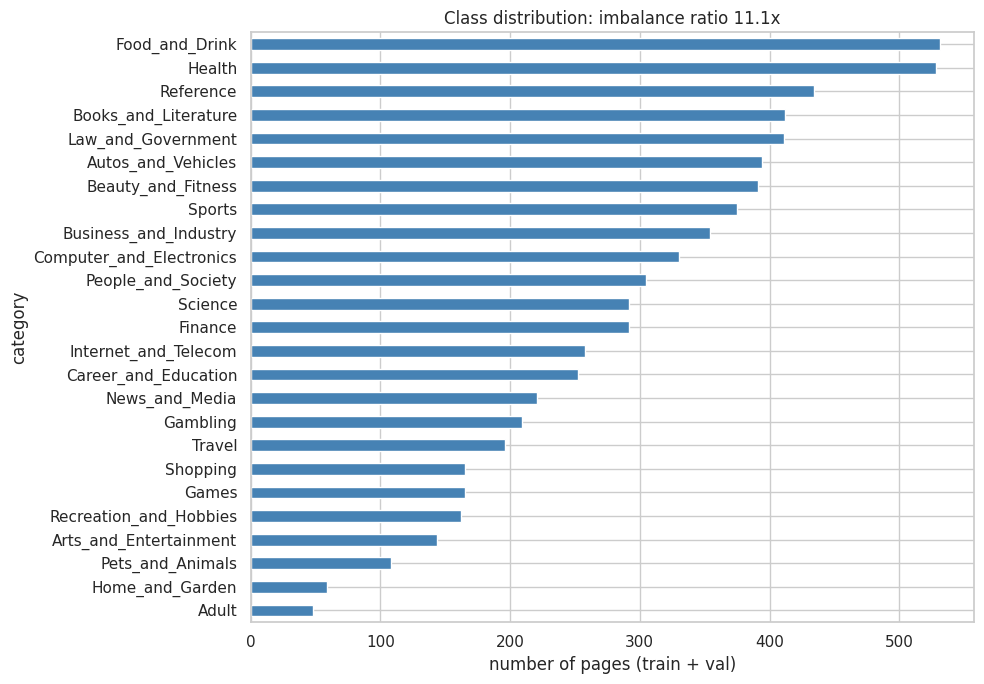

largest: Food_and_Drink (531)   smallest: Adult (48)


In [3]:
counts = full["category"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("number of pages (train + val)")
ax.set_title(f"Class distribution: imbalance ratio {counts.max() / counts.min():.1f}x")
fig.tight_layout()
fig.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()
print(f"largest: {counts.idxmax()} ({counts.max()})   smallest: {counts.idxmin()} ({counts.min()})")

## Content length: raw HTML vs extracted text

The `extract.py` step (trafilatura) strips boilerplate, so the extracted text is
shorter than the raw HTML. Extraction is a pipeline stage, not free
preprocessing (Web2Text, BoilerNet).

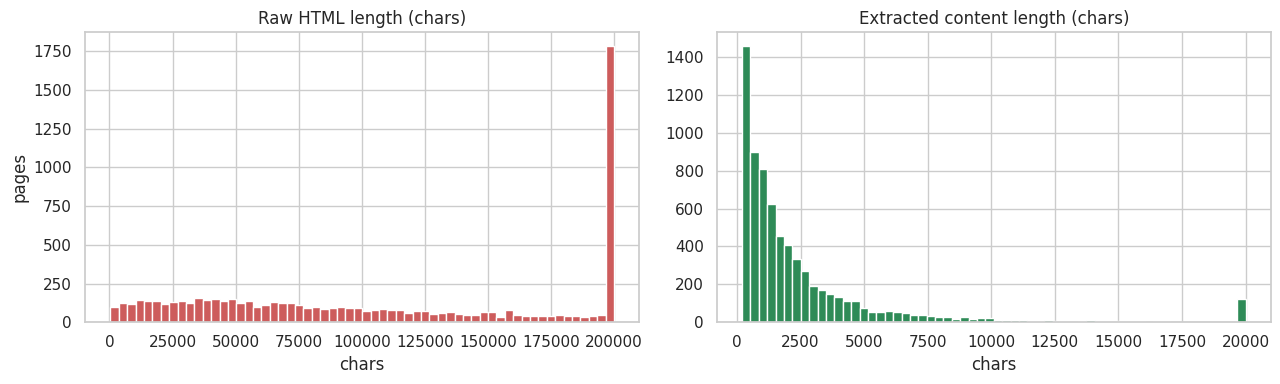

         html_len  content_len
count      7036.0       7036.0
mean     178157.0       3137.0
std      361182.0      14796.0
min         380.0        200.0
25%       44491.0        629.0
50%       96112.0       1369.0
75%      198562.0       2877.0
max    16089649.0    1088947.0


In [4]:
full = full.assign(content_len=full["content"].str.len())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(full["html_len"].clip(upper=200_000), bins=60, color="indianred")
axes[0].set(title="Raw HTML length (chars)", xlabel="chars", ylabel="pages")
axes[1].hist(full["content_len"].clip(upper=20_000), bins=60, color="seagreen")
axes[1].set(title="Extracted content length (chars)", xlabel="chars")
fig.tight_layout()
fig.savefig(FIG_DIR / "content_length.png", dpi=150)
plt.show()
print(full[["html_len", "content_len"]].describe().round(0))

## Token-length distribution under the ModernBERT tokenizer

This informs the sequence-length choice and quantifies the truncation rate at
256, 512, and 1024 tokens, the hyperparameter Nandanwar & Choudhary (2023)
found most impactful.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (15418 > 8192). Running this sequence through the model will result in indexing errors


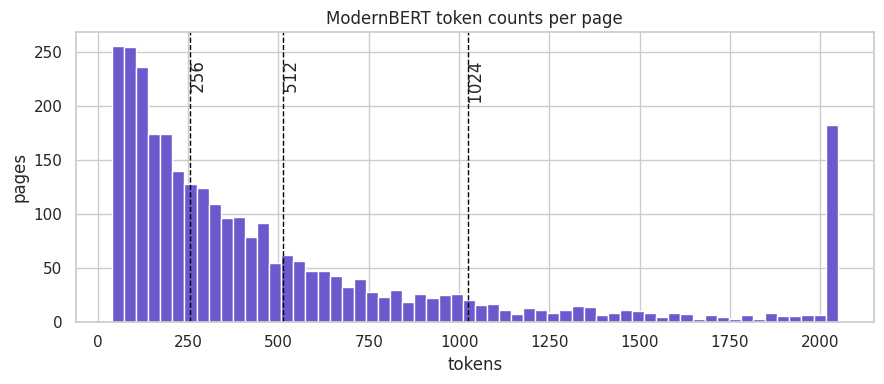

truncation rate (fraction of pages longer than the limit):
    256 tokens:  56.7%   median tokens: 310
    512 tokens:  32.4%   median tokens: 310
   1024 tokens:  15.0%   median tokens: 310


In [5]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
sample = full["content"].sample(min(3000, len(full)), random_state=42).tolist()
tok_lens = pd.Series([len(x) for x in tok(sample, truncation=False)["input_ids"]])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tok_lens.clip(upper=2048), bins=60, color="slateblue")
for L in (256, 512, 1024):
    ax.axvline(L, color="black", ls="--", lw=1)
    ax.text(L, ax.get_ylim()[1] * 0.9, f" {L}", rotation=90, va="top")
ax.set(title="ModernBERT token counts per page", xlabel="tokens", ylabel="pages")
fig.tight_layout()
fig.savefig(FIG_DIR / "token_lengths.png", dpi=150)
plt.show()

print("truncation rate (fraction of pages longer than the limit):")
for L in (256, 512, 1024):
    print(f"  {L:>5} tokens: {(tok_lens > L).mean():6.1%}   median tokens: {tok_lens.median():.0f}")

## Language mix

We keep English-only pages; the non-English share found during cleaning:

In [6]:
for split in ("train", "test"):
    s = report[f"clean_{split}"]
    print(f"{split}: non-English {s['non_english']} pages ({s['non_english_share']:.1%}), dropped")

train: non-English 4342 pages (38.0%), dropped
test: non-English 1130 pages (38.3%), dropped


## Example extractions

Qualitative check of the HTML->content step.

In [7]:
for _, row in full.sample(3, random_state=1).iterrows():
    print(f"[{row['category']}]  {row['url']}")
    print(f"  {row['content'][:300]}...")
    print()

[Science]  indiarailinfo.com
  Spotting Timeline Travel Tip Trip Race Social Greeting Poll Img PNR Pic Blog News Conf TL RF Club Convention Monitor Topic # Rating Correct Wrong Stamp PNR Ref PNR Req Blank PNRs HJ Vote Pred @ FM Alert FM Approval Pvt Search Trains ▼ Search Categories Search Trains (A->B) Search Departures/Arrivals...

[People_and_Society]  muslimphilosophy.com
  | ISLAMIC PHILOSOPHY ONLINE HAS MOVED TO THE FOLLOWING www.muslimphilosophy.org | | | MOVED MOVED MOVED MOVED MOVED | A GREAT NEW HOME A BETTER NEW HOME Click here to go to muslimphilosophy.org or muslim philosophy website has moved to Ghazali.org A WONDERFUL NEW HOME NEW HOME WHERE THE HEART IS WE ...

[Sports]  riveraveblues.com
  I’m going to let you all in on a little secret. There has never been a moment — not once — where I felt like I deserved the recognition or praise that came my way for RAB. I’m not oblivious to the site’s success and to this day I have a hard time wrapping my head around it, but I don

## Top TF-IDF terms per class

The most discriminative vocabulary per category, a check that the text signal
separates classes, and a preview of confusable pairs.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), stop_words="english",
                      min_df=5, sublinear_tf=True)
X = vec.fit_transform(full["content"])
terms = vec.get_feature_names_out()
for cat in label_names[:8]:
    mask = (full["category"] == cat).to_numpy()
    mean_tfidf = X[mask].mean(axis=0).A1
    top = mean_tfidf.argsort()[::-1][:10]
    print(f"{cat:<26} {', '.join(terms[i] for i in top)}")

Adult                      world, site, new, 2023, com, 18, help, best, sex, free
Arts_and_Entertainment     awards, website, 2023, free, new, videos, art, video, site, photos
Autos_and_Vehicles         car, vehicle, parts, new, cars, service, vehicles, ford, 2023, performance
Beauty_and_Fitness         hair, skin, body, beauty, fitness, products, tattoo, care, salon, best
Books_and_Literature       books, book, author, new, writing, read, writers, fiction, poetry, life
Business_and_Industry      products, business, solutions, 2023, service, industry, help, new, learn, use
Career_and_Education       students, education, school, learn, student, 2023, learning, help, online, information
Computer_and_Electronics   software, data, use, tools, support, free, windows, users, new, solutions


## Word clouds for selected classes

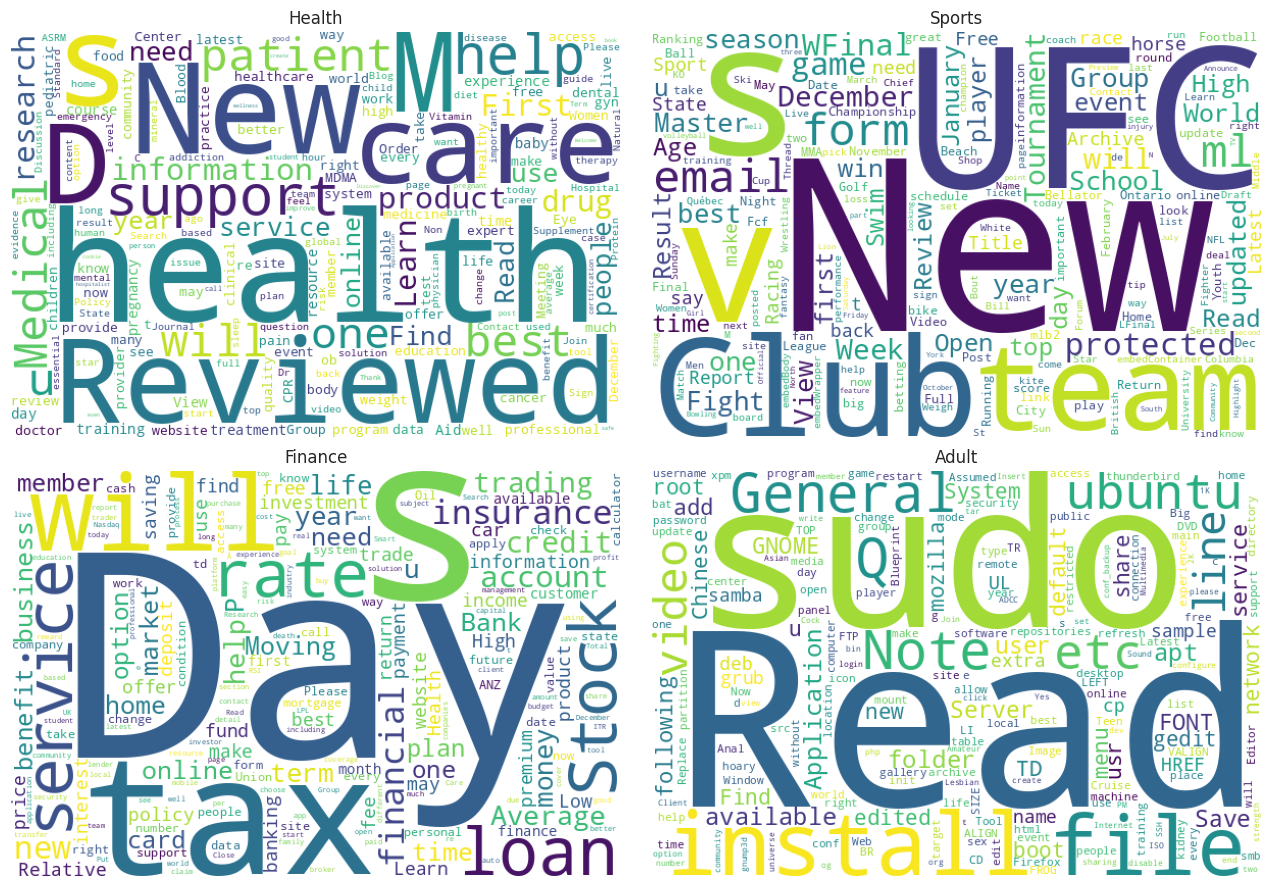

In [9]:
from wordcloud import WordCloud

show = ["Health", "Sports", "Finance", "Adult"]
show = [c for c in show if c in set(full["category"])][:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, cat in zip(axes.flat, show):
    text = " ".join(full.loc[full["category"] == cat, "content"].head(300))
    wc = WordCloud(width=600, height=400, background_color="white",
                   stopwords=None, collocations=False).generate(text)
    ax.imshow(wc); ax.axis("off"); ax.set_title(cat)
fig.tight_layout()
fig.savefig(FIG_DIR / "wordclouds.png", dpi=150)
plt.show()

## Takeaways

The data has 25 classes with class imbalance, which is why macro-F1 is the
headline metric and the loss is class-weighted. Trafilatura shrinks pages by
roughly 10 to 20 times, so extraction is a distinct pipeline stage. The
token-length statistics inform the 256/512/1024 sequence-length ablation. After
de-leaking there is zero train/test overlap, and the cleaning report is
reproducible.